# LSOA Sampling — Selecting a Representative 1000-LSOA Sample

The full dataset has ~35,000 LSOAs. Running cross-validation on all of them takes too long for quick analytics. This notebook selects ~1000 LSOAs that are representative of the whole UK in terms of:
- **Geographic coverage**  every local authority is included
- **Crime volume diversity**  mix of low, medium, and high crime areas

The result is saved to `data/sample_1000_lsoas.json` and used by `src/scripts/run_cv_sample.py`.

In [2]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_PATH   = "../data/all_lsoa__monthly_counts.csv"
OUTPUT_PATH = "../data/sample_1000_lsoas.json"
TARGET_N    = 1000
SEED        = 42

## 1. Load data and compute per-LSOA crime totals

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,}  |  Date range: {df['Month'].min()} → {df['Month'].max()}")
print(f"Unique LSOAs: {df['LSOA code'].nunique():,}")

Rows: 5,787,798  |  Date range: 2023-04-01 → 2026-02-01
Unique LSOAs: 35,705


In [4]:
# Total crime per LSOA across all months and crime types
lsoa_totals = (
    df.groupby(["LSOA code", "LSOA name"], as_index=False)["crime_count"]
    .sum()
    .rename(columns={"crime_count": "total_crimes"})
)

# Extract local authority: strip trailing " 001A"-style suffix
lsoa_totals["local_authority"] = lsoa_totals["LSOA name"].str.replace(
    r"\s+\d{3}[A-Z]$", "", regex=True
)
lsoa_totals["country"] = lsoa_totals["LSOA code"].str[0].map({"E": "England", "W": "Wales"})

print(f"LSOAs: {len(lsoa_totals):,}")
print(f"Local authorities: {lsoa_totals['local_authority'].nunique()}")
print(f"\nEngland / Wales split:")
print(lsoa_totals['country'].value_counts())

LSOAs: 35,705
Local authorities: 351

England / Wales split:
country
England    33729
Wales       1976
Name: count, dtype: int64


## 2. Understand the distributions

Before sampling, look at how LSOAs are distributed across local authorities and crime volumes.

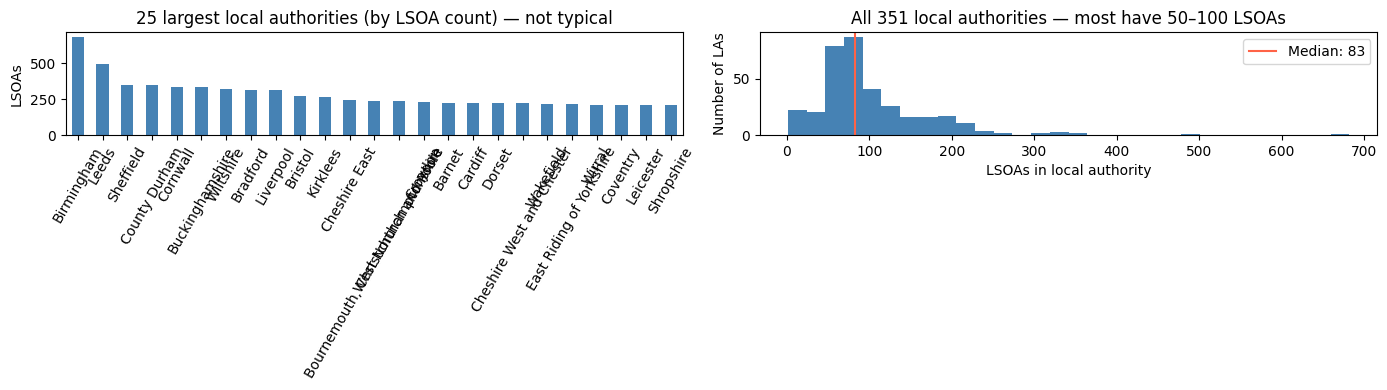

LAs with fewer than 5 LSOAs : 20
LAs with more than 100 LSOAs: 125
Median LSOAs per LA         : 83
Mean LSOAs per LA           : 102


In [5]:
la_sizes = lsoa_totals.groupby("local_authority")["LSOA code"].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

la_sizes.head(25).plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("25 largest local authorities (by LSOA count) — not typical")
axes[0].set_xlabel("")
axes[0].set_ylabel("LSOAs")
axes[0].tick_params(axis="x", rotation=60)

axes[1].hist(la_sizes, bins=30, color="steelblue", edgecolor="none")
axes[1].set_title(f"All {la_sizes.shape[0]} local authorities — most have 50–100 LSOAs")
axes[1].set_xlabel("LSOAs in local authority")
axes[1].set_ylabel("Number of LAs")
axes[1].axvline(la_sizes.median(), color="tomato", linewidth=1.5, label=f"Median: {la_sizes.median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"LAs with fewer than 5 LSOAs : {(la_sizes < 5).sum()}")
print(f"LAs with more than 100 LSOAs: {(la_sizes > 100).sum()}")
print(f"Median LSOAs per LA         : {la_sizes.median():.0f}")
print(f"Mean LSOAs per LA           : {la_sizes.mean():.0f}")

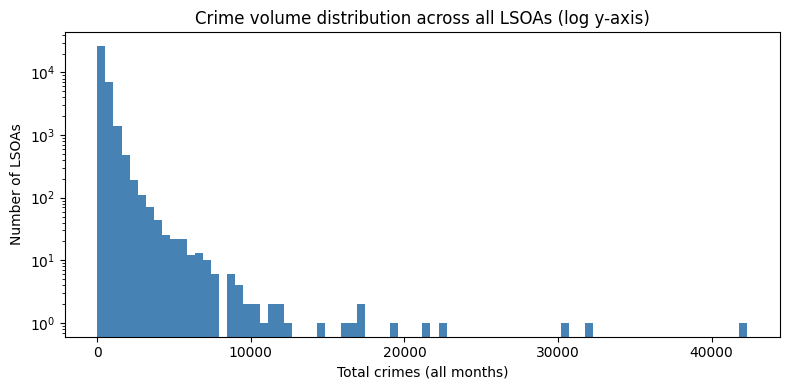

count    35705.0
mean       467.0
std        702.0
min          1.0
25%        188.0
50%        322.0
75%        548.0
max      42334.0
Name: total_crimes, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lsoa_totals["total_crimes"], bins=80, color="steelblue", edgecolor="none", log=True)
ax.set_title("Crime volume distribution across all LSOAs (log y-axis)")
ax.set_xlabel("Total crimes (all months)")
ax.set_ylabel("Number of LSOAs")
plt.tight_layout()
plt.show()

print(lsoa_totals["total_crimes"].describe().round(0))

## 3. Sampling strategy

**Why crime-volume decile stratification?**  

Dividing all LSOAs into **10 equal crime-volume deciles** and drawing 100 from each forces the sample distribution to match the full population  every part of the crime spectrum is equally represented.

**Geographic coverage:**  
Within each decile, LSOAs are drawn so as many different local authorities as possible are included (sampling without replacement, shuffling before selection).

In [7]:
rng = np.random.default_rng(SEED)

N_DECILES    = 10
PER_DECILE   = TARGET_N // N_DECILES   # 100 per decile

lsoa_totals["decile"] = pd.qcut(lsoa_totals["total_crimes"], q=N_DECILES, labels=False)

print(f"LSOAs per decile (should be ~{len(lsoa_totals) // N_DECILES}):")
print(lsoa_totals["decile"].value_counts().sort_index())

LSOAs per decile (should be ~3570):
decile
0    3577
1    3585
2    3626
3    3536
4    3554
5    3598
6    3558
7    3531
8    3571
9    3569
Name: count, dtype: int64


In [8]:
sampled = []

for decile, group in lsoa_totals.groupby("decile"):
    # Shuffle so LSOAs from different LAs are interleaved, then take the first PER_DECILE
    shuffled = group.sample(frac=1, random_state=rng.integers(1e6))
    sampled.append(shuffled.head(PER_DECILE))

sample_df = pd.concat(sampled, ignore_index=True)
print(f"Sample size: {len(sample_df)}")
print(f"LAs covered: {sample_df['local_authority'].nunique()} / {lsoa_totals['local_authority'].nunique()}")

Sample size: 1000
LAs covered: 292 / 351


## 4. Validate the sample

In [9]:
# England / Wales breakdown
print("Country split in sample:")
print(sample_df["country"].value_counts())
print()
print("Country split in full population:")
print(lsoa_totals["country"].value_counts())

Country split in sample:
country
England    953
Wales       47
Name: count, dtype: int64

Country split in full population:
country
England    33729
Wales       1976
Name: count, dtype: int64


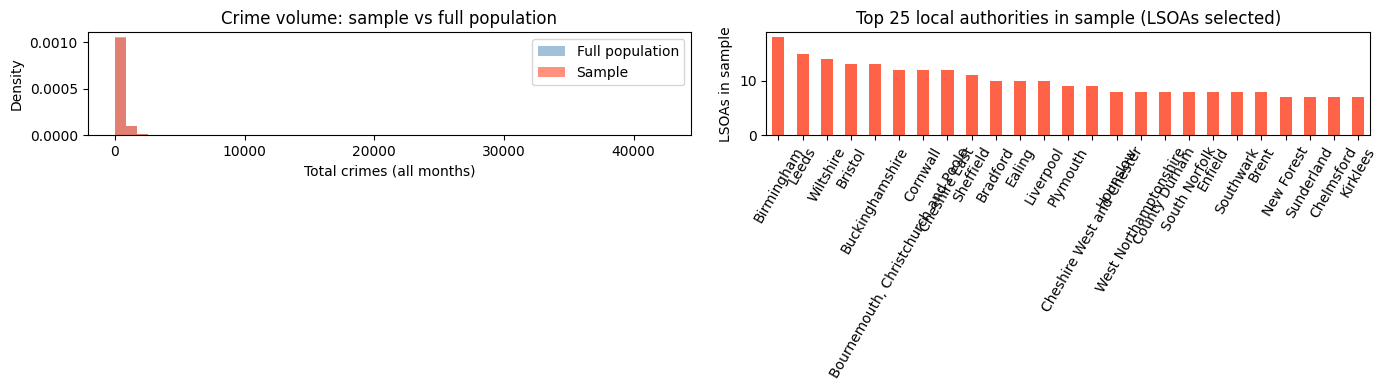

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Crime volume: sample vs full population
bins = np.histogram_bin_edges(lsoa_totals["total_crimes"], bins=50)
axes[0].hist(lsoa_totals["total_crimes"], bins=bins, density=True,
             alpha=0.5, label="Full population", color="steelblue", edgecolor="none")
axes[0].hist(sample_df["total_crimes"], bins=bins, density=True,
             alpha=0.7, label="Sample", color="tomato", edgecolor="none")
axes[0].set_title("Crime volume: sample vs full population")
axes[0].set_xlabel("Total crimes (all months)")
axes[0].set_ylabel("Density")
axes[0].legend()

# LAs covered — how many LSOAs sampled per LA (top 25)
sample_per_la = sample_df.groupby("local_authority")["LSOA code"].count().sort_values(ascending=False)
sample_per_la.head(25).plot(kind="bar", ax=axes[1], color="tomato", edgecolor="none")
axes[1].set_title("Top 25 local authorities in sample (LSOAs selected)")
axes[1].set_xlabel("")
axes[1].set_ylabel("LSOAs in sample")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

In [11]:
# Summary stats comparison
comparison = pd.DataFrame({
    "Full population": lsoa_totals["total_crimes"].describe(),
    "Sample":          sample_df["total_crimes"].describe(),
}).round(0)
print(comparison)

       Full population  Sample
count          35705.0  1000.0
mean             467.0   474.0
std              702.0   605.0
min                1.0     1.0
25%              188.0   189.0
50%              322.0   322.0
75%              548.0   529.0
max            42334.0  7064.0


## 5. Save the sample

In [12]:
lsoa_list = sample_df["LSOA code"].tolist()

with open(OUTPUT_PATH, "w") as f:
    json.dump({"lsoas": lsoa_list}, f, indent=2)

print(f"Saved {len(lsoa_list)} LSOA codes to {OUTPUT_PATH}")
print(f"\nNext step: run  python -m src.scripts.run_cv_sample")

Saved 1000 LSOA codes to ../data/sample_1000_lsoas.json

Next step: run  python -m src.scripts.run_cv_sample
